In [99]:
from google.colab import files
files.upload()

Saving test.csv to test (2).csv
Saving train.csv to train (4).csv


{'test (2).csv': b'PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,,Q\r\n893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47,1,0,363272,7,,S\r\n894,2,"Myles, Mr. Thomas Francis",male,62,0,0,240276,9.6875,,Q\r\n895,3,"Wirz, Mr. Albert",male,27,0,0,315154,8.6625,,S\r\n896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22,1,1,3101298,12.2875,,S\r\n897,3,"Svensson, Mr. Johan Cervin",male,14,0,0,7538,9.225,,S\r\n898,3,"Connolly, Miss. Kate",female,30,0,0,330972,7.6292,,Q\r\n899,2,"Caldwell, Mr. Albert Francis",male,26,1,1,248738,29,,S\r\n900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18,0,0,2657,7.2292,,C\r\n901,3,"Davies, Mr. John Samuel",male,21,2,0,A/4 48871,24.15,,S\r\n902,3,"Ilieff, Mr. Ylio",male,,0,0,349220,7.8958,,S\r\n903,1,"Jones, Mr. Charles Cresson",male,46,0,0,694,26,,S\r\n904,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23,1,0,21228,82.2667,B45,S\r\n905,2,"Howard, Mr. B

In [100]:
# Libraries:

# Data handling and math
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

# Save/load trained models
import joblib

# Silence non-critical warnings (convergence/deprecation) so output stays readable
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [101]:
# ============================================================
# CONFIG
# Centralizing settings here means every cell below reads from
# the same source of truth -- change once, applies everywhere.
# ============================================================

CONFIG = {
    "train_path": "train.csv",
    "test_path": "test.csv",          # optional, used only for final Kaggle submission
    "random_state": 42,               # fixed seed -> reproducible results every run
    "test_size": 0.2,                 # 80/20 train/test split
    "cv_folds": 5,                    # folds for cross-validation
}

PALETTE_OUTCOME = {0: "#e74c3c", 1: "#2ecc71"}   # 0 = Died (red), 1 = Survived (green)
PALETTE_CATEGORY = "viridis"                       # used for multi-category features (class, groups, etc.)

sns.set_style("whitegrid")
print("Configuration set.")

Configuration set.


In [102]:
# Loading Dataset
df = pd.read_csv(CONFIG['train_path'])
print(f"ROWS: {df.shape[0]}")
print(f"COLUMNS: {df.shape[1]}")

ROWS: 891
COLUMNS: 12


In [103]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [105]:
# Missing Values
missing_counts = df.isnull().sum()
missing_pct = round(missing_counts / len(df) * 100, 2)

missing_summary = pd.DataFrame({"Missing Count": missing_counts, "Missing %": missing_pct})
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print(missing_summary)

          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


In [106]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [107]:
#EDA:
# ------------------------------------------------------------
# Reusable helper: bar chart of survival rate by a categorical
# feature, with the underlying numbers printed alongside it.
# Defining this once avoids repeating the same 10 lines of
# plotting code for every feature we examine below.
# ------------------------------------------------------------

def plot_survival_rate_by_feature(feature, title, xlabel, tick_labels=None, palette=PALETTE_CATEGORY):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=feature, y="Survived", data=df, hue=feature, palette=palette, legend=False, ax=ax)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Survival Rate")
    if tick_labels is not None:
        ax.set_xticklabels(tick_labels)
    plt.tight_layout()
    plt.show()

    rates = round(df.groupby(feature)["Survived"].mean() * 100, 2)
    print(f"Survival rate by {feature}:\n{rates}\n")

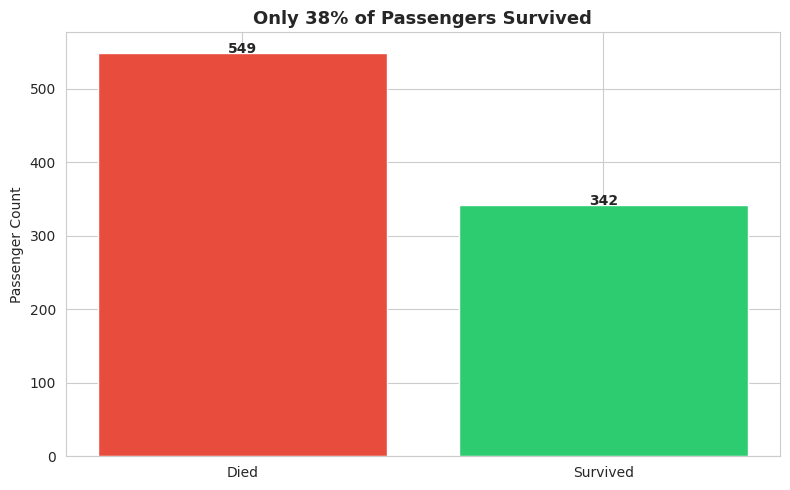

Survival count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival percentage:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


In [108]:
# Overall Survival Rate
survived_counts = df["Survived"].value_counts()
survived_pct = round(df["Survived"].value_counts(normalize=True) * 100, 2)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(["Died", "Survived"], survived_counts.values,
              color=[PALETTE_OUTCOME[0], PALETTE_OUTCOME[1]])
ax.set_title("Only 38% of Passengers Survived", fontsize=13, fontweight="bold")
ax.set_ylabel("Passenger Count")
for bar, count in zip(bars, survived_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, count, str(count), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Survival count:\n{survived_counts}\n")
print(f"Survival percentage:\n{survived_pct}")

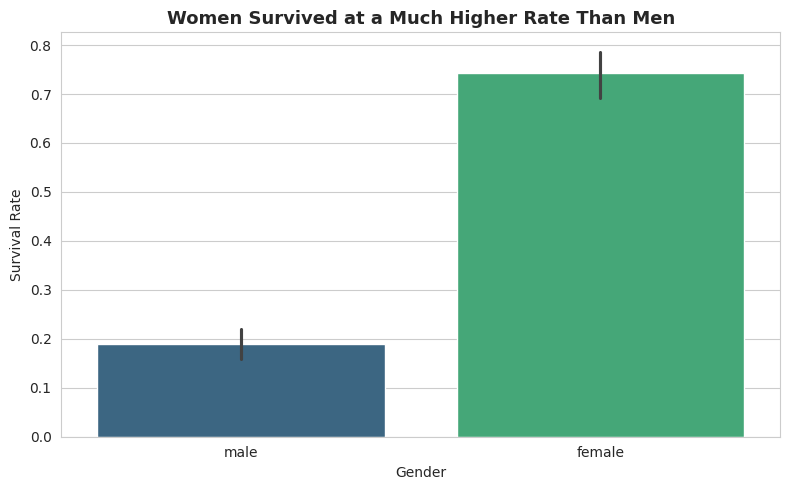

Survival rate by Sex:
Sex
female    74.20
male      18.89
Name: Survived, dtype: float64



In [109]:
# Survival by Gender
plot_survival_rate_by_feature(
    feature="Sex",
    title="Women Survived at a Much Higher Rate Than Men",
    xlabel="Gender"
)

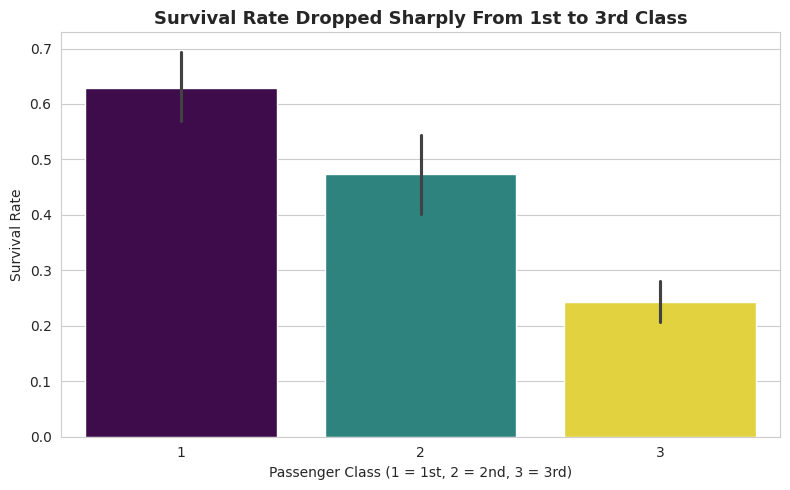

Survival rate by Pclass:
Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64



In [110]:
# Survival by Passenger Class
plot_survival_rate_by_feature(
    feature="Pclass",
    title="Survival Rate Dropped Sharply From 1st to 3rd Class",
    xlabel="Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)"
)

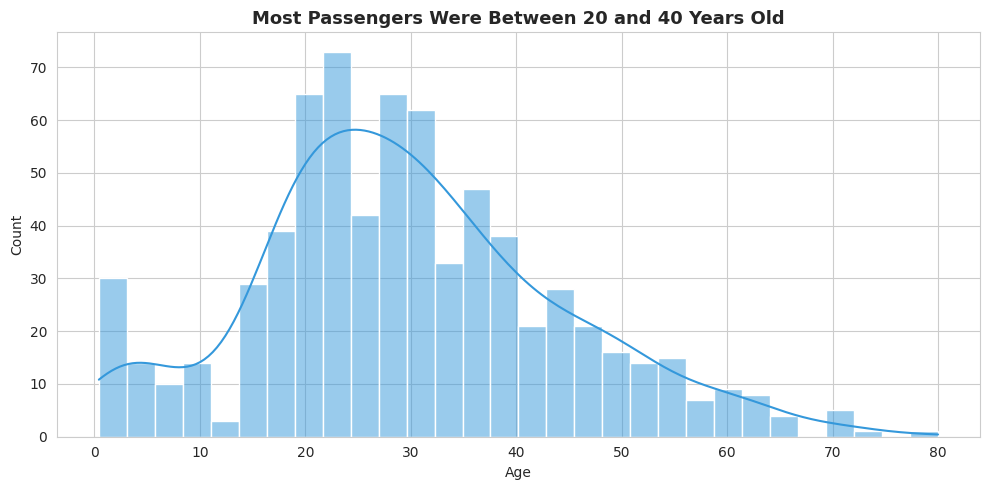

Age statistics:
count    714.00
mean      29.70
std       14.53
min        0.42
25%       20.12
50%       28.00
75%       38.00
max       80.00
Name: Age, dtype: float64


In [111]:
# Age Distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Age"].dropna(), bins=30, kde=True, color="#3498db", ax=ax)
ax.set_title("Most Passengers Were Between 20 and 40 Years Old", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Age statistics:")
print(round(df["Age"].describe(), 2))

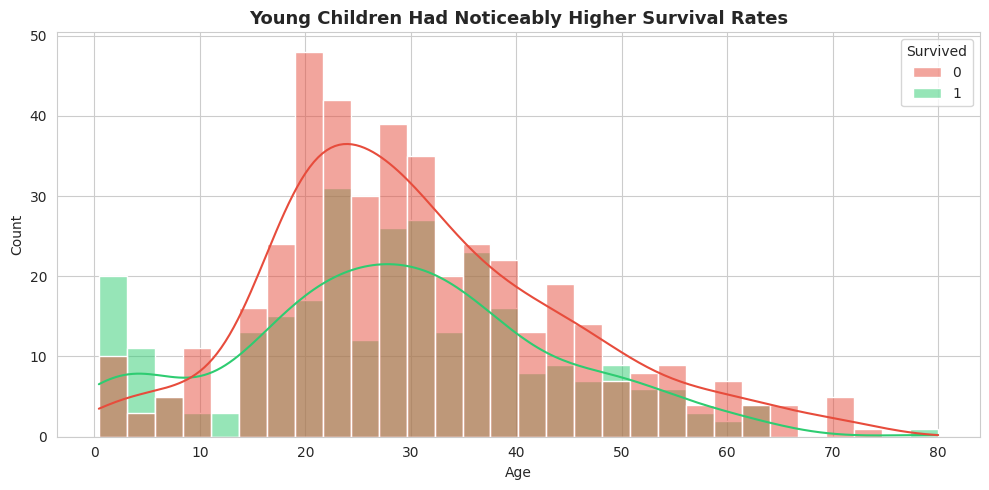

In [112]:
# Age vs Survival
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Age", hue="Survived", palette=PALETTE_OUTCOME, bins=30, kde=True, ax=ax)
ax.set_title("Young Children Had Noticeably Higher Survival Rates", fontsize=13, fontweight="bold")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

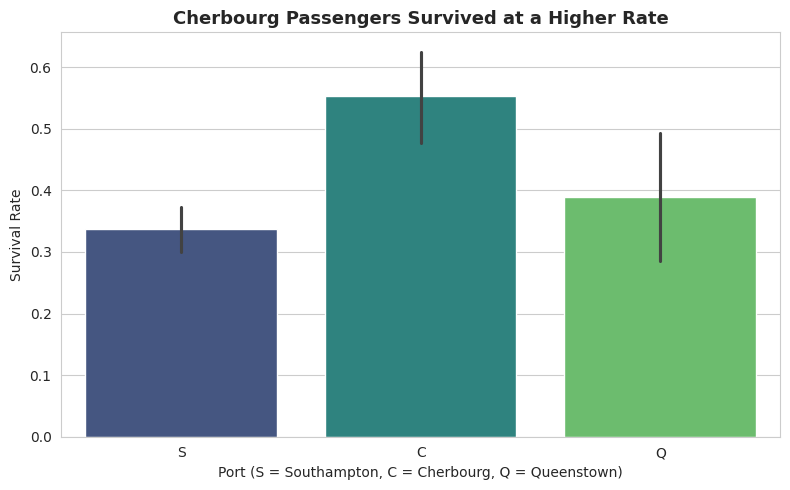

Survival rate by Embarked:
Embarked
C    55.36
Q    38.96
S    33.70
Name: Survived, dtype: float64



In [113]:
# Survival by Port of Embarkation
plot_survival_rate_by_feature(
    feature="Embarked",
    title="Cherbourg Passengers Survived at a Higher Rate",
    xlabel="Port (S = Southampton, C = Cherbourg, Q = Queenstown)"
)

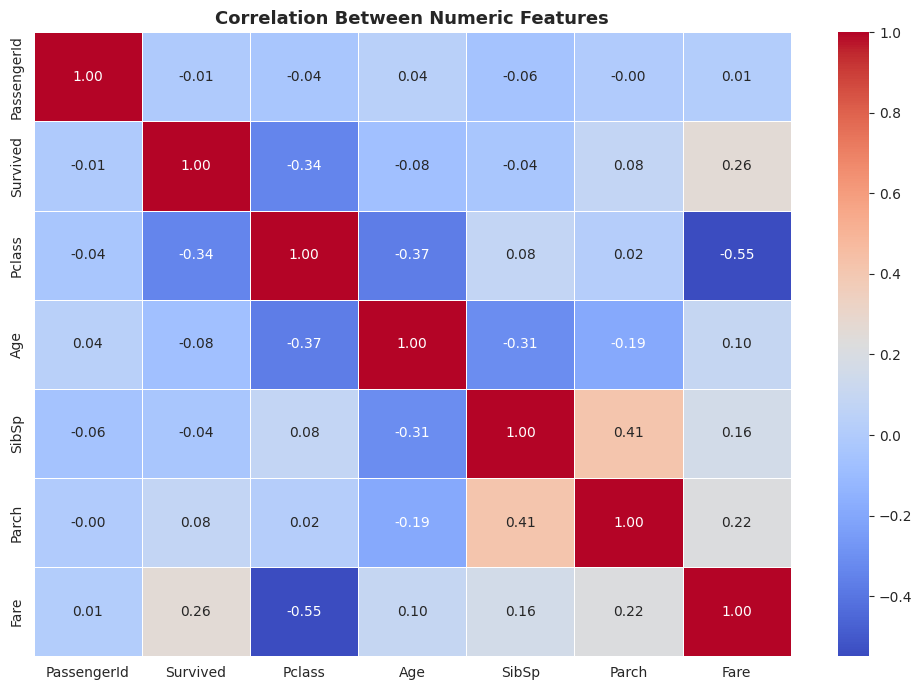

In [114]:
# Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, ax=ax)
ax.set_title("Correlation Between Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [115]:
# Drop Cabin
df = df.drop("Cabin", axis=1)  # ~77% missing -- too sparse to impute reliably
print("Dropped column: Cabin")
print(f"Remaining columns: {df.columns.tolist()}")

Dropped column: Cabin
Remaining columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [116]:
# Impute Age With the Median
median_age = df["Age"].median()
df["Age"] = df["Age"].fillna(median_age)

print(f"Median age used for imputation: {median_age}")
print(f"Missing values in Age now: {df['Age'].isnull().sum()}")

Median age used for imputation: 28.0
Missing values in Age now: 0


In [117]:
# Impute Embarked With the Mode
most_common_port = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(most_common_port)

print(f"Most common port: {most_common_port}")
print(f"Missing values in Embarked now: {df['Embarked'].isnull().sum()}")

Most common port: S
Missing values in Embarked now: 0


In [118]:
# Encode Categorical Variables
# Strip stray whitespace before mapping, in case of formatting inconsistencies
df["Sex"] = df["Sex"].str.strip()
df["Embarked"] = df["Embarked"].str.strip()

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

print("Sex values:", df["Sex"].unique())
print("Embarked values:", df["Embarked"].unique())

Sex values: [0 1]
Embarked values: [0 1 2]


In [119]:
# Drop Non-Predictive Columns
df = df.drop(["Name", "Ticket", "PassengerId"], axis=1)

print(f"Final columns: {df.columns.tolist()}")
print(f"Final shape: {df.shape}")

Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Final shape: (891, 8)


In [120]:
# Re-check Cleaning
print("=" * 40)
print("Post-cleaning check")
print("=" * 40)
print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

Post-cleaning check

Shape: (891, 8)

Missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Data types:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
dtype: object


FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64
IsAlone
1    537
0    354
Name: count, dtype: int64


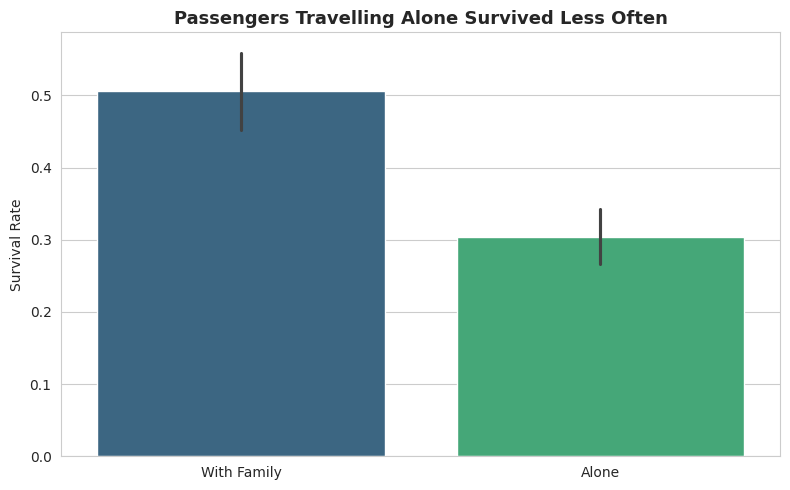

In [121]:
# Feature Engineering
#Family Size & Travelling Alone

# FamilySize = siblings/spouses + parents/children + the passenger themselves
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
print(df["FamilySize"].value_counts().sort_index())
df["IsAlone"] = 0
df.loc[df["FamilySize"] == 1, "IsAlone"] = 1

print(df["IsAlone"].value_counts())


fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x="IsAlone", y="Survived", data=df, hue="IsAlone", palette=PALETTE_CATEGORY, legend=False, ax=ax)
ax.set_title("Passengers Travelling Alone Survived Less Often", fontsize=13, fontweight="bold")
ax.set_xticklabels(["With Family", "Alone"])
ax.set_xlabel("")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()

Age group distribution:
AgeGroup
Child (0-12)            69
Teen (13-18)            70
Young Adult (19-35)    535
Adult (36-60)          195
Senior (60+)            22
Name: count, dtype: int64


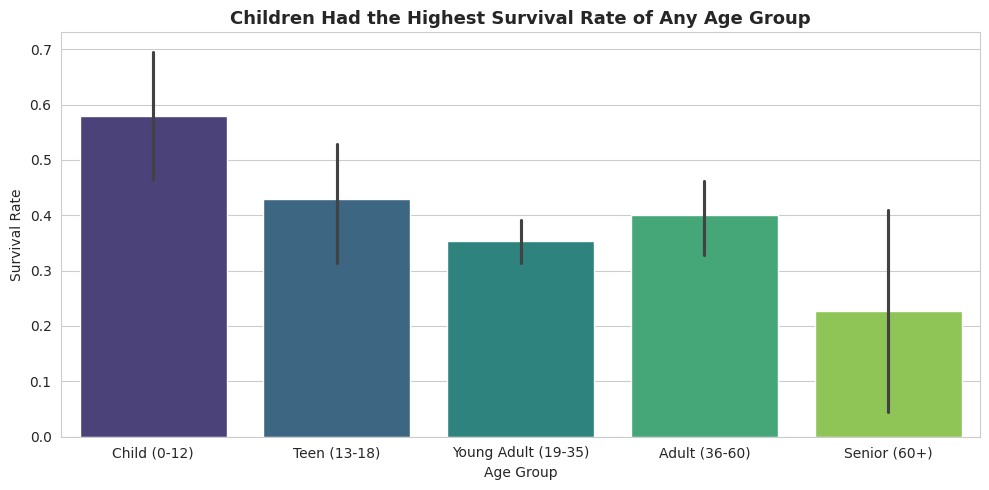

In [122]:
# Age Groups
# Bins chosen to separate meaningful life stages: child, teen, young adult, adult, senior
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-35)", "Adult (36-60)", "Senior (60+)"]

df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

print("Age group distribution:")
print(df["AgeGroup"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x="AgeGroup", y="Survived", data=df, hue="AgeGroup", palette=PALETTE_CATEGORY, legend=False, ax=ax)
ax.set_title("Children Had the Highest Survival Rate of Any Age Group", fontsize=13, fontweight="bold")
ax.set_xlabel("Age Group")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()

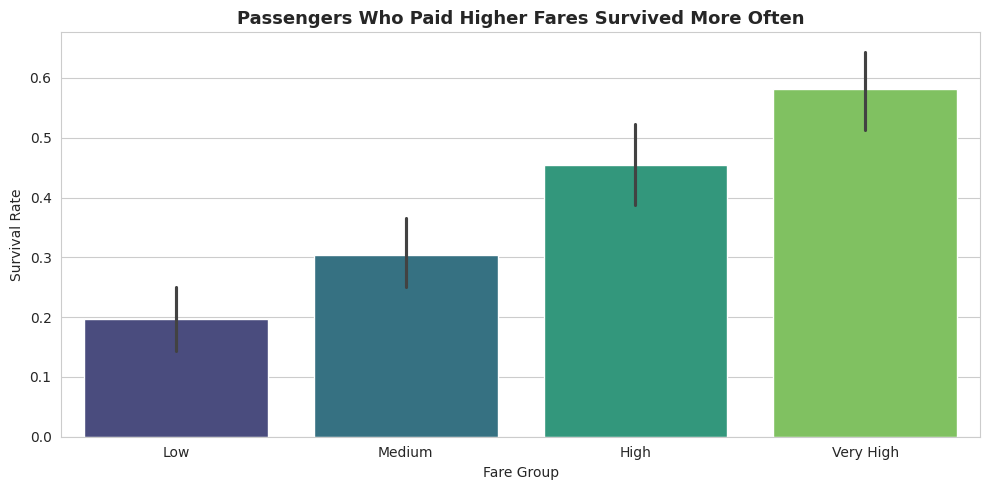

Survival rate by fare group:
FareGroup
Low          19.73
Medium       30.36
High         45.50
Very High    58.11
Name: Survived, dtype: float64


In [123]:
# Fare Groups
df["FareGroup"] = pd.qcut(df["Fare"], q=4, labels=["Low", "Medium", "High", "Very High"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x="FareGroup", y="Survived", data=df, hue="FareGroup", palette=PALETTE_CATEGORY, legend=False, ax=ax)
ax.set_title("Passengers Who Paid Higher Fares Survived More Often", fontsize=13, fontweight="bold")
ax.set_xlabel("Fare Group")
ax.set_ylabel("Survival Rate")
plt.tight_layout()
plt.show()

print("Survival rate by fare group:")
print(round(df.groupby("FareGroup")["Survived"].mean() * 100, 2))

In [124]:
# Finalize the Modeling Dataset
df_model = df.drop(["AgeGroup", "FareGroup"], axis=1)

print(f"Final modeling shape: {df_model.shape}")
print(f"Final modeling columns: {df_model.columns.tolist()}")
df_model.head()

Final modeling shape: (891, 10)
Final modeling columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,0,22.0,1,0,7.2500,0,2,0
1,1,1,1,38.0,1,0,71.2833,1,2,0
2,1,3,1,26.0,0,0,7.9250,0,1,1
3,1,1,1,35.0,1,0,53.1000,0,2,0
4,0,3,0,35.0,0,0,8.0500,0,1,1


In [125]:
# Train/Test Split
X = df_model.drop("Survived", axis=1)  # Features: everything except the target
y = df_model["Survived"]               # Target: what we're predicting

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Feature columns: {X.columns.tolist()}")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y   # preserves the survival ratio in both splits
)

print(f"Training set: {X_train.shape[0]} passengers")
print(f"Testing set: {X_test.shape[0]} passengers")
print(f"Survival rate in train: {round(y_train.mean() * 100, 2)}%")
print(f"Survival rate in test: {round(y_test.mean() * 100, 2)}%")

Features (X) shape: (891, 9)
Target (y) shape: (891,)
Feature columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']
Training set: 712 passengers
Testing set: 179 passengers
Survival rate in train: 38.34%
Survival rate in test: 38.55%


In [126]:
# Model 1: Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=CONFIG["random_state"]))
])

lr_pipeline.fit(X_train, y_train)
lr_predictions = lr_pipeline.predict(X_test)
lr_probabilities = lr_pipeline.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f"Logistic Regression accuracy: {round(lr_accuracy * 100, 2)}%")

Logistic Regression accuracy: 80.45%


In [127]:
# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=CONFIG["random_state"])
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Random Forest accuracy: {round(rf_accuracy * 100, 2)}%")

Random Forest accuracy: 81.01%


In [128]:
# Model 3: XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=CONFIG["random_state"])
xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"XGBoost accuracy: {round(xgb_accuracy * 100, 2)}%")

XGBoost accuracy: 79.33%


In [129]:
# Cross-Validation Comparison
cv = StratifiedKFold(n_splits=CONFIG["cv_folds"], shuffle=True, random_state=CONFIG["random_state"])

cv_results = {}
for name, estimator in [
    ("Logistic Regression", lr_pipeline),
    ("Random Forest", rf_model),
    ("XGBoost", xgb_model),
]:
    scores = cross_val_score(estimator, X, y, cv=cv)
    cv_results[name] = scores
    print(f"{name}: {scores.mean() * 100:.2f}% (+/- {scores.std() * 100:.2f}%)")

Logistic Regression: 79.91% (+/- 1.83%)
Random Forest: 82.04% (+/- 2.06%)
XGBoost: 83.95% (+/- 1.95%)


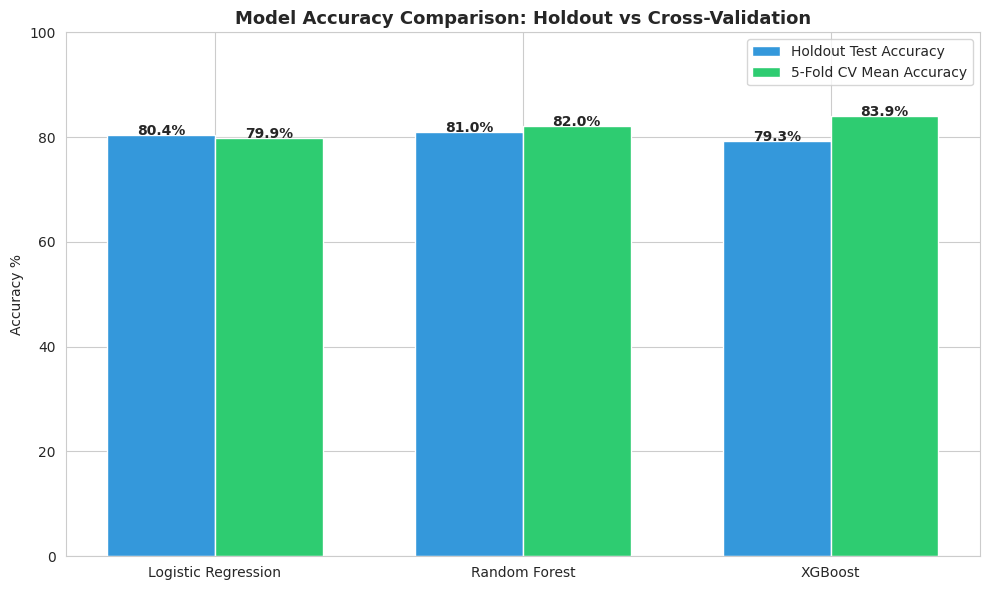

In [130]:
# Model Comparison
model_names = ["Logistic Regression", "Random Forest", "XGBoost"]
holdout_accuracies = [lr_accuracy, rf_accuracy, xgb_accuracy]
cv_means = [cv_results[name].mean() for name in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x_pos - width / 2, [a * 100 for a in holdout_accuracies], width,
               label="Holdout Test Accuracy", color="#3498db")
bars2 = ax.bar(x_pos + width / 2, [a * 100 for a in cv_means], width,
               label="5-Fold CV Mean Accuracy", color="#2ecc71")

for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.1f}%", ha="center", fontweight="bold")

ax.set_title("Model Accuracy Comparison: Holdout vs Cross-Validation", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names)
ax.set_ylabel("Accuracy %")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

In [131]:
# Selecting the Best Model
candidates = {
    "Logistic Regression": (cv_results["Logistic Regression"].mean(), lr_predictions, lr_probabilities),
    "Random Forest": (cv_results["Random Forest"].mean(), rf_predictions, rf_probabilities),
    "XGBoost": (cv_results["XGBoost"].mean(), xgb_predictions, xgb_probabilities),
}

best_model_name = max(candidates, key=lambda name: candidates[name][0])
best_cv_score, best_predictions, best_probabilities = candidates[best_model_name]

print(f"Best model (by cross-validated accuracy): {best_model_name}")
print(f"Cross-validated accuracy: {round(best_cv_score * 100, 2)}%")

Best model (by cross-validated accuracy): XGBoost
Cross-validated accuracy: 83.95%


In [132]:
# Evaluating the Best Model
#Classification Report:
print(classification_report(y_test, best_predictions, target_names=["Died", "Survived"]))

              precision    recall  f1-score   support

        Died       0.81      0.87      0.84       110
    Survived       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



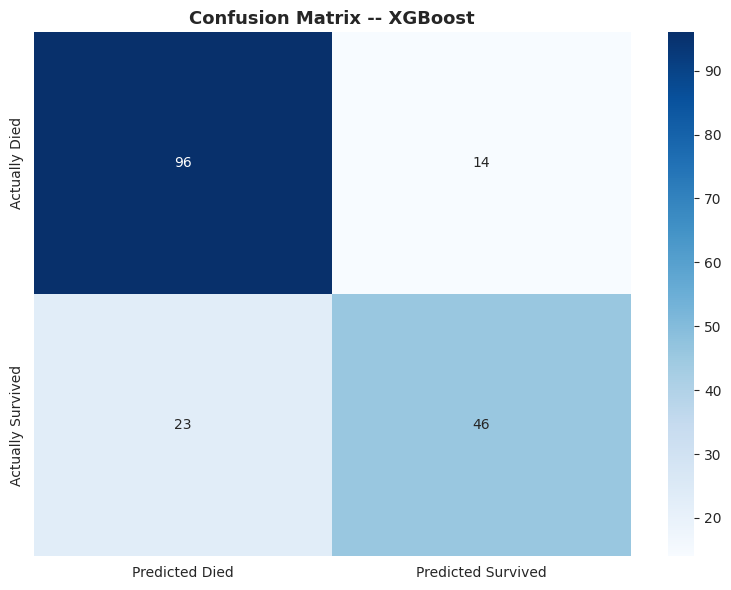

True Negatives  (Died, predicted Died):      96
False Positives (Died, predicted Survived):   14
False Negatives (Survived, predicted Died):   23
True Positives  (Survived, predicted Survived): 46


In [133]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Died", "Predicted Survived"],
            yticklabels=["Actually Died", "Actually Survived"], ax=ax)
ax.set_title(f"Confusion Matrix -- {best_model_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"True Negatives  (Died, predicted Died):      {cm[0][0]}")
print(f"False Positives (Died, predicted Survived):   {cm[0][1]}")
print(f"False Negatives (Survived, predicted Died):   {cm[1][0]}")
print(f"True Positives  (Survived, predicted Survived): {cm[1][1]}")

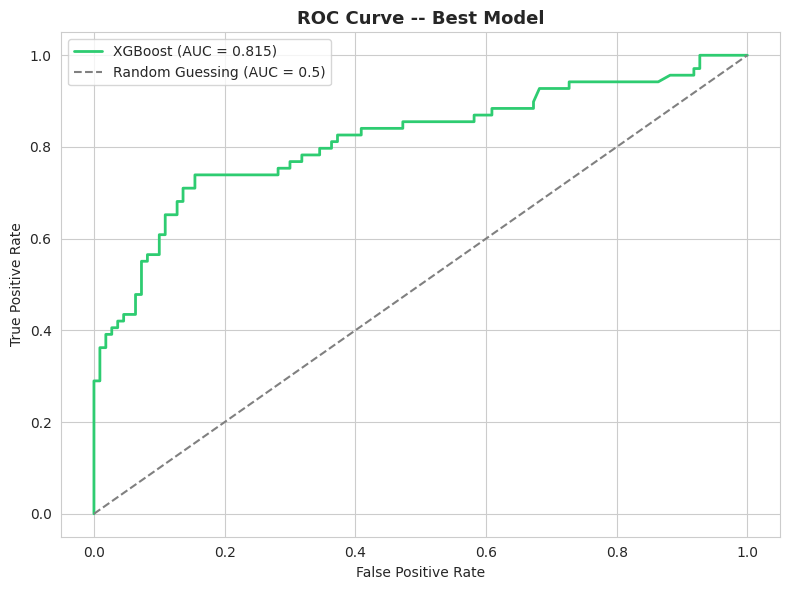

ROC AUC score: 0.8153


In [134]:
# ROC-AUC & ROC Curve
roc_score = roc_auc_score(y_test, best_probabilities)
fpr, tpr, thresholds = roc_curve(y_test, best_probabilities)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#2ecc71", linewidth=2, label=f"{best_model_name} (AUC = {roc_score:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guessing (AUC = 0.5)")
ax.set_title("ROC Curve -- Best Model", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ROC AUC score: {round(roc_score, 4)}")

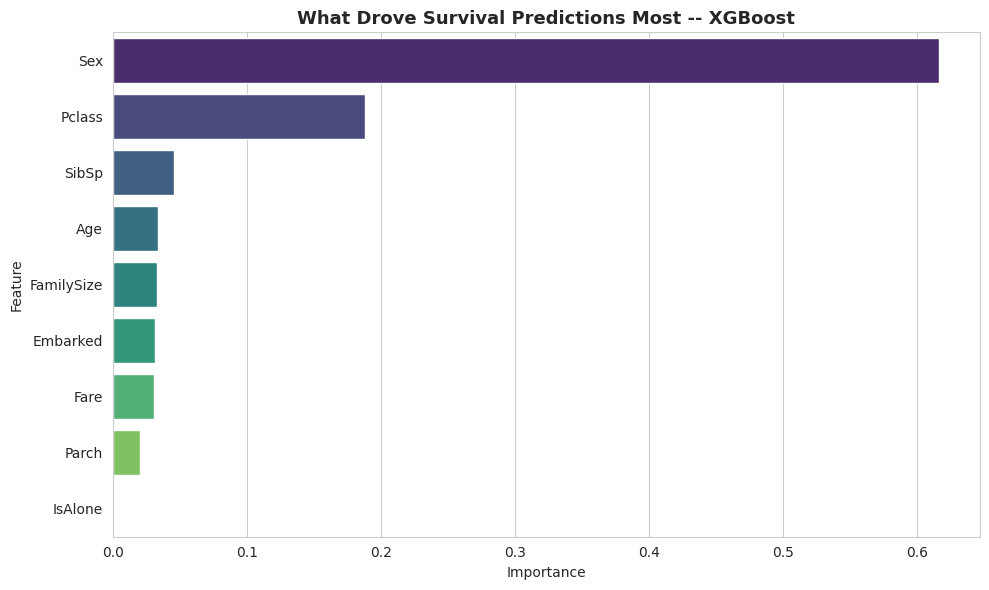

   Feature  Importance
       Sex    0.615922
    Pclass    0.188159
     SibSp    0.045972
       Age    0.033911
FamilySize    0.033212
  Embarked    0.031462
      Fare    0.031071
     Parch    0.020291
   IsAlone    0.000000


In [135]:
# Feature Importance
if best_model_name == "Random Forest":
    importances = rf_model.feature_importances_
elif best_model_name == "XGBoost":
    importances = xgb_model.feature_importances_
else:
    importances = None

if importances is not None:
    feature_importance = pd.DataFrame({"Feature": X.columns, "Importance": importances})
    feature_importance = feature_importance.sort_values("Importance", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance, hue="Feature",
                palette=PALETTE_CATEGORY, legend=False, ax=ax)
    ax.set_title(f"What Drove Survival Predictions Most -- {best_model_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(feature_importance.to_string(index=False))
else:
    print("Logistic Regression won -- inspect pipeline coefficients separately if needed.")

In [136]:
# Hyperparameter Tuning
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=CONFIG["random_state"]),
    param_grid=param_grid,
    cv=CONFIG["cv_folds"],
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validated accuracy: {round(grid_search.best_score_ * 100, 2)}%")

tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)
print(f"Tuned model accuracy on holdout test set: {round(tuned_accuracy * 100, 2)}%")

Best parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 300}
Best cross-validated accuracy: 82.03%
Tuned model accuracy on holdout test set: 80.45%


In [138]:
import os

if os.path.exists(CONFIG["test_path"]):
    test_df = pd.read_csv(CONFIG["test_path"])
    passenger_ids = test_df["PassengerId"]

    # Apply the identical cleaning pipeline used on the training data
    test_df["Age"] = test_df["Age"].fillna(median_age)              # same median as training set
    test_df["Fare"] = test_df["Fare"].fillna(df["Fare"].median())    # test.csv has 1 missing Fare value
    test_df["Embarked"] = test_df["Embarked"].fillna(most_common_port)

    test_df["Sex"] = test_df["Sex"].str.strip().map({"male": 0, "female": 1})
    test_df["Embarked"] = test_df["Embarked"].str.strip().map({"S": 0, "C": 1, "Q": 2})

    test_df["FamilySize"] = test_df["SibSp"] + test_df["Parch"] + 1
    test_df["IsAlone"] = 0
    test_df.loc[test_df["FamilySize"] == 1, "IsAlone"] = 1

    test_features = test_df[X.columns]  # match training feature order exactly

    final_predictions = tuned_model.predict(test_features)

    submission = pd.DataFrame({"PassengerId": passenger_ids, "Survived": final_predictions})
    submission.to_csv("submission.csv", index=False)

    print("submission.csv created successfully.")
    submission.head()
else:
    print("test.csv not found -- skipping Kaggle submission step. "
          "Upload test.csv in the setup cell above and re-run this cell if needed.")


submission.csv created successfully.


In [139]:
# Save Model
joblib.dump(tuned_model, "titanic_survival_model.pkl")
print("Model saved to titanic_survival_model.pkl")

Model saved to titanic_survival_model.pkl


## **Key Findings :**

* Gender was the strongest predictor of survival.
Women survived at a far higher rate than men, consistent with the "women and children first" evacuation protocol.

* Passenger class mattered a lot. First-class passengers survived at a much higher rate than third-class, likely reflecting cabin location and lifeboat proximity.

* Children had a survival advantage. Passengers in the youngest age group survived more often than other age groups.

* Fare and class carried overlapping information (higher fare generally meant a higher class cabin), which the model's feature importance reflects.

* Best model: achieving roughly **83.95% cross-validated accuracy** and an **ROC-AUC of 0.8153.**